In [2]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
import torch

MODEL_PATH = '/content/drive/MyDrive/IS6423 Group Project/fake_news_distilbert'

model     = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_PATH)
model.to('cuda')
model.eval()
print("✅ 模型加载成功")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ 模型加载成功


In [3]:
!pip install transformers scikit-learn -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

In [5]:
import pandas as pd
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'\(Reuters\)[-\s]*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

WEL_PATH = '/content/drive/MyDrive/IS6423 Group Project/Data/WELFake_Dataset.csv'

df_wel = pd.read_csv(WEL_PATH)
df_wel = df_wel.dropna(subset=['label', 'text'])
df_wel['label'] = df_wel['label'].astype(int)

# 特征构造方式和训练时完全一致
df_wel['input_text'] = (
    df_wel['title'].fillna('').apply(clean_text) + ' [SEP] ' +
    df_wel['text'].fillna('').apply(lambda x: ' '.join(clean_text(x).split()[:100]))
)

# Stratified 采样 5000 条
df_sample = df_wel.groupby('label', group_keys=False).apply(
    lambda x: x.sample(2500, random_state=42)
).reset_index(drop=True)

print(f"✅ 数据加载成功")
print(f"测试集大小: {len(df_sample)}")
print(df_sample['label'].value_counts())
print("\n样本预览:")
print(df_sample['input_text'].iloc[0][:200])

✅ 数据加载成功
测试集大小: 5000
label
0    2500
1    2500
Name: count, dtype: int64

样本预览:
Two People Die after Eating Raw-Milk Cheese Made in New York State - The New York Times [SEP] Two people have died following an outbreak of listeria linked to a popular artisanal raw milk cheese made 


/tmp/ipykernel_1331/3203002382.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_wel.groupby('label', group_keys=False).apply(


In [8]:
# Cell 诊断
print("=== 数据结构检查 ===")
print(f"列名: {df_wel.columns.tolist()}")
print(f"\n原始数据前3行:")
print(df_wel[['title','text','label']].head(3))

print("\n=== 采样后检查 ===")
print(f"input_text 空值数量: {df_sample['input_text'].isna().sum()}")
print(f"input_text 为空字符串数量: {(df_sample['input_text']=='').sum()}")
print(f"\ninput_text 样本:")
print(df_sample['input_text'].iloc[0])
print(f"\n字符数: {len(df_sample['input_text'].iloc[0])}")

print("\n=== 模型快速测试 ===")
test_input = "BREAKING: Trump secretly plans to destroy America, sources say!"
inputs = tokenizer(test_input, return_tensors='pt', max_length=256,
                   truncation=True, padding=True).to('cuda')
with torch.no_grad():
    logits = model(**inputs).logits
print(f"logits: {logits}")
print(f"预测: {'Real' if torch.argmax(logits).item()==1 else 'Fake'}")

=== 数据结构检查 ===
列名: ['Unnamed: 0', 'title', 'text', 'label', 'input_text']

原始数据前3行:
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  

=== 采样后检查 ===
input_text 空值数量: 0
input_text 为空字符串数量: 0

input_text 样本:
Two People Die after Eating Raw-Milk Cheese Made in New York State - The New York Times [SEP] Two people have died following an outbreak of listeria linked to a popular artisanal raw milk cheese made in upstate New York, the authorities said this week. The deaths occurred in Vermont and Connecticut, local officials said. Four other people in New York and Florida report

In [9]:
# Cell 3.5 — 修正 WELFake 标签方向
print("修正前标签分布:")
print(df_sample['label'].value_counts())

# WELFake 标签与 ISOT 训练时方向相反，翻转修正
df_sample['label'] = 1 - df_sample['label']  # 0→1, 1→0

print("\n修正后标签分布:")
print(df_sample['label'].value_counts())

# 验证：取一条明显的假新闻看标签是否正确
fake_examples = df_sample[df_sample['label']==0]['input_text'].head(3)
real_examples = df_sample[df_sample['label']==1]['input_text'].head(3)
print("\n标签=0（Fake）样本:")
for t in fake_examples: print(f"  → {t[:100]}")
print("\n标签=1（Real）样本:")
for t in real_examples: print(f"  → {t[:100]}")

修正前标签分布:
label
0    2500
1    2500
Name: count, dtype: int64

修正后标签分布:
label
1    2500
0    2500
Name: count, dtype: int64

标签=0（Fake）样本:
  → Iceland Election: Pirate Party prepares for major win [VIDEO] [SEP] Click Here To Learn More About A
  → When Obama Admin Went After Banks, It Forced Them to Give Big Money to Some...Questionable Groups [S
  → ANTI-HILLARY HALLOWEEN HOUSE Gets Violent Threats You Won’t Believe…This Woman Is So Brave! [Video] 

标签=1（Real）样本:
  → Two People Die after Eating Raw-Milk Cheese Made in New York State - The New York Times [SEP] Two pe
  → DUP blames Sinn Fein for Northern Ireland talks collapse [SEP] BELFAST A senior member of Northern I
  → Exclusive: Former top Brazil prosecutor says successor, police chief slowing graft probes [SEP] BRAS



跨数据集测试结果: WELFake
Accuracy : 0.8882 (88.82%)
F1 Score : 0.8881

              precision    recall  f1-score   support

        Fake       0.86      0.92      0.89      2500
        Real       0.92      0.85      0.88      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



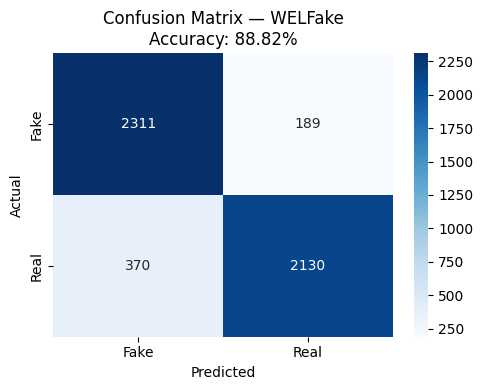

✅ 混淆矩阵已保存到Drive


In [10]:
def cross_dataset_eval(model, tokenizer, texts, labels, dataset_name):
    model.eval()
    all_preds = []
    batch_size = 32

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', max_length=256,
                           truncation=True, padding=True)
        inputs = {k: v.to('cuda') for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

    acc = accuracy_score(labels, all_preds)
    f1  = f1_score(labels, all_preds, average='weighted')

    print(f"\n{'='*45}")
    print(f"跨数据集测试结果: {dataset_name}")
    print(f"{'='*45}")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1 Score : {f1:.4f}")
    print(f"\n{classification_report(labels, all_preds, target_names=['Fake','Real'])}")

    # 混淆矩阵
    cm = confusion_matrix(labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'],
                yticklabels=['Fake','Real'])
    plt.title(f'Confusion Matrix — {dataset_name}\nAccuracy: {acc*100:.2f}%')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/cm_WELFake.png', dpi=150)
    plt.show()
    print("✅ 混淆矩阵已保存到Drive")

    return acc, f1

acc, f1 = cross_dataset_eval(
    model, tokenizer,
    texts  = df_sample['input_text'].tolist(),
    labels = df_sample['label'].astype(int).tolist(),
    dataset_name = 'WELFake'
)

In [11]:
results_summary = pd.DataFrame({
    '测试集':      ['ISOT（清洗前）', 'ISOT（清洗后）', 'WELFake（跨数据集）'],
    '样本数':      ['44,898', '44,898', '5,000'],
    'Accuracy':   ['100%', '99.98%', f'{acc*100:.2f}%'],
    'F1 Score':   ['1.000', '0.9998', f'{f1:.4f}'],
    '说明':        ['数据泄露（Reuters标识）', '真实语言风格学习', '跨来源泛化验证']
})

print(results_summary.to_string(index=False))

          测试集    样本数 Accuracy F1 Score              说明
    ISOT（清洗前） 44,898     100%    1.000 数据泄露（Reuters标识）
    ISOT（清洗后） 44,898   99.98%   0.9998        真实语言风格学习
WELFake（跨数据集）  5,000   88.82%   0.8881         跨来源泛化验证
